In [17]:
import numpy as np
import matplotlib.pyplot as plt





In [7]:

import numpy as np
x = np.linspace(0, 4, 5)
y = np.linspace(0, 6, 7)
X, Y = np.meshgrid(x, y, indexing='xy')   
X,Y



(array([[0., 1., 2., 3., 4.],
        [0., 1., 2., 3., 4.],
        [0., 1., 2., 3., 4.],
        [0., 1., 2., 3., 4.],
        [0., 1., 2., 3., 4.],
        [0., 1., 2., 3., 4.],
        [0., 1., 2., 3., 4.]]),
 array([[0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 1.],
        [2., 2., 2., 2., 2.],
        [3., 3., 3., 3., 3.],
        [4., 4., 4., 4., 4.],
        [5., 5., 5., 5., 5.],
        [6., 6., 6., 6., 6.]]))

In [8]:
F = X**2 + Y**2

dF_dy, dF_dx = np.gradient(F, y, x, edge_order=2)

print(dF_dx[3,2], dF_dy[3,2])

4.0 6.0


[[ 3.00000000e+00  4.00000000e+00]
 [-3.33333333e-01  1.50000000e+00]
 [ 2.38095238e-02  1.02380952e+00]
 [-2.64550265e-03  1.00396825e+00]
 [ 1.88964475e-04  1.00018896e+00]
 [-2.09960527e-05  1.00003149e+00]
 [ 1.49971805e-06  1.00000150e+00]
 [-1.66635339e-07  1.00000025e+00]
 [ 1.19025242e-08  1.00000001e+00]]


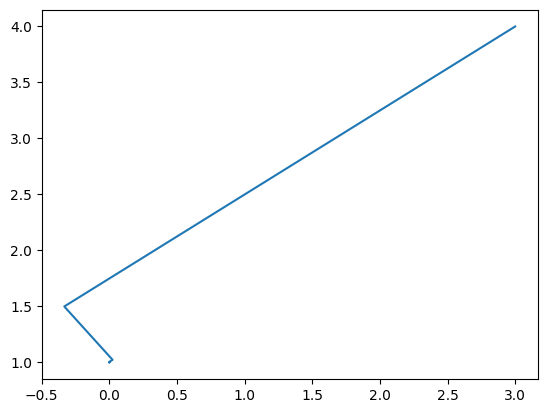

In [29]:
A=np.array([[3,1],[1,2]])
b=np.array([1,2])

x=np.array([3,4])
points=[x.copy()]
tol=10e-8

max_iter = 10

for i in range(max_iter):
    r=b-A@x
    if np.linalg.norm(r)<tol:
        break

    alpha = (r@r)/(r@A@r)
    x=x+alpha*r
    
    points.append(x.copy())

points=np.array(points)

print(points)
plt.plot(points[:,0],points[:,1])






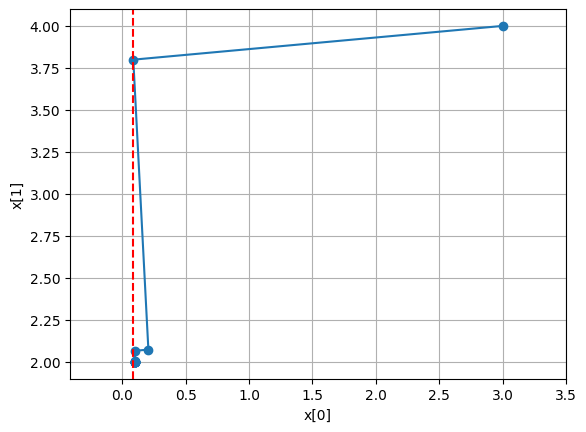

In [4]:
import numpy as np
import matplotlib.pyplot as plt

A = np.array([[10,0],[0,1]])
b = np.array([1,2])

x = np.array([3,4])
points = [x.copy()]
tol = 1e-8
max_iter = 100

for i in range(max_iter):
    r = b - A @ x
    if np.linalg.norm(r) < tol:
        break
    Ar = A @ r
    alpha = (r @ r) / (r @ Ar)
    x = x + alpha * r
    points.append(x.copy())

points = np.array(points)




plt.plot(points[:,0], points[:,1], '-o', markersize=6)
plt.axvline(points[:,0][1], color='r', linestyle='--')  
plt.xlim(points[:,0].min() - 0.5, points[:,0].max() + 0.5)
plt.xlabel('x[0]')
plt.ylabel('x[1]')
plt.grid(True)
plt.show()




[[ 3.          4.        ]
 [-0.33333333  0.66666667]]
-0.33333333333333304 3.0


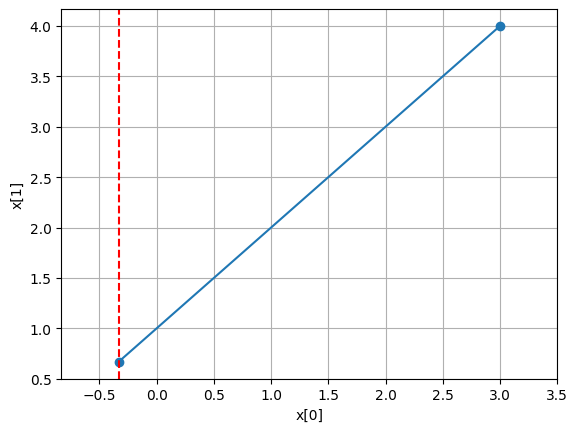

In [2]:


import matplotlib.pyplot as plt
print(points)                 # inspect all points
print(points[:,0].min(), points[:,0].max())

plt.plot(points[:,0], points[:,1], '-o', markersize=6)
plt.axvline(points[:,0][1], color='r', linestyle='--')  # mark the first update
plt.xlim(points[:,0].min() - 0.5, points[:,0].max() + 0.5)
plt.xlabel('x[0]')
plt.ylabel('x[1]')
plt.grid(True)
plt.show()

In [6]:
import numpy as np


x_old=np.array([1,1])
x=x_old[0]
y=x_old[1]

TOL = 10**(-8)
max_iter =1000
F = x**2 + y**2

for i in range(max_iter):
    x=x_old[0]
    y=x_old[1]
    dF_dy, dF_dx = np.gradient(F, y, x, edge_order=2)
    



TypeError: invalid number of arguments

In [8]:
x_old=np.array([1,1])
x_old[0]

np.int64(1)

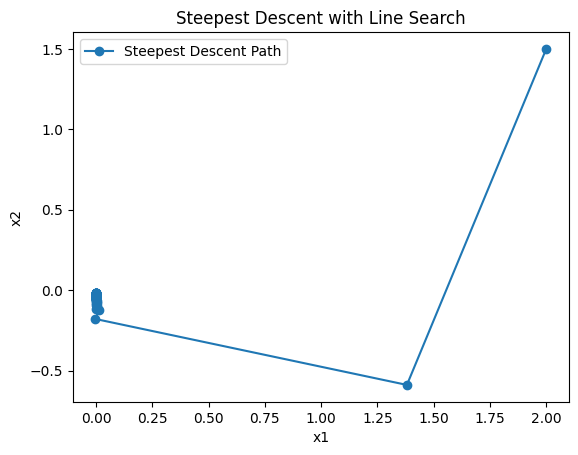

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Function
def f(x):
    return x[0]**2 + x[1]**4

# Gradient
def grad_f(x):
    return np.array([2*x[0], 4*x[1]**3])

# Line search using Newton method
def find_alpha(x, p, tol=1e-6, max_iter=20):
    alpha = 0.0   # initial guess

    for _ in range(max_iter):
        # phi'(alpha)
        x_new = x + alpha * p
        grad = grad_f(x_new)
        phi_prime = np.dot(grad, p)

        # phi''(alpha)
        # Hessian
        H = np.array([[2, 0],
                      [0, 12*x_new[1]**2]])
        phi_double = p.T @ H @ p

        # Avoid division by zero
        if abs(phi_double) < 1e-10:
            break

        alpha_new = alpha - phi_prime / phi_double

        if abs(alpha_new - alpha) < tol:
            return alpha_new

        alpha = alpha_new

    return alpha


# Steepest Descent Algorithm
def steepest_descent(x0, tol=1e-6, max_iter=100):
    x = x0.copy()
    history = [x.copy()]

    for _ in range(max_iter):
        grad = grad_f(x)

        # stopping condition
        if np.linalg.norm(grad) < tol:
            break

        p = -grad

        # compute optimal step size
        alpha = find_alpha(x, p)

        # update
        x = x + alpha * p
        history.append(x.copy())

    return np.array(history)


# Initial point
x0 = np.array([2.0, 1.5])

# Run algorithm
path = steepest_descent(x0)


plt.plot(path[:,0], path[:,1], 'o-', label='Steepest Descent Path')

plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.title('Steepest Descent with Line Search')
plt.show()

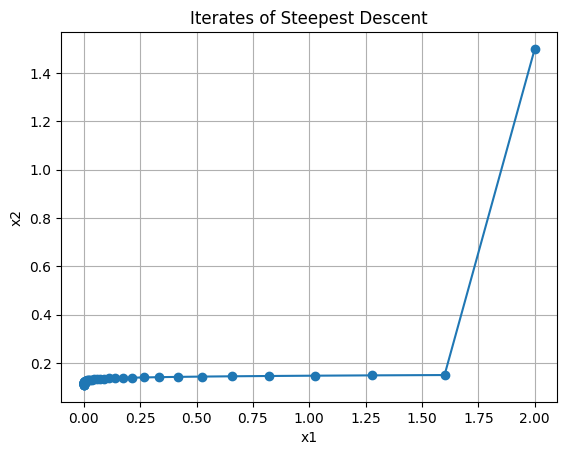

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Function and gradient

def f(x):
    return x[0]**2 + x[1]**4

def grad_f(x):
    return np.array([2*x[0], 4*x[1]**3])

# Steepest Descent

def steepest_descent(x0, alpha=0.1, max_iter=50):
    x = x0.copy()
    history = [x.copy()]


    for _ in range(max_iter):
        x = x - alpha * grad_f(x)
        history.append(x.copy())

    return np.array(history)


# Initial point

x0 = np.array([2.0, 1.5])
path = steepest_descent(x0)

# Plot iterates 

plt.plot(path[:,0], path[:,1], 'o-')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Iterates of Steepest Descent')
plt.grid()
plt.show()